In [32]:
import pandas as pd
data=pd.read_csv('crop_production_cameroon.csv')
print("Rows in the dataset:", data.shape[0])
print("Columns in the dataset:", data.columns.tolist())
print("Minimum value in year column:",data['Year'].min())
print("Maximum value in year column:",data['Year'].max())
print("Unique Crop values Names:",data['Item'].nunique())
print("Unique Element values Names:",data['Element'].nunique())
print("Unique Units values Names:",data['Unit'].nunique())
print("Count of each flag values in the dataset:",data['Flag'].value_counts())
print(data.isna().sum())

data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
data["Value"] = pd.to_numeric(data["Value"], errors="coerce")

data["Item"] = data["Item"].astype("string").str.strip()
data["Element"] = data["Element"].astype("string").str.strip()
data["Area"] = data["Area"].astype("string").str.strip()

print(data[["Year", "Value", "Item", "Element", "Area"]].dtypes)

Rows in the dataset: 7156
Columns in the dataset: ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']
Minimum value in year column: 2000
Maximum value in year column: 2024
Unique Crop values Names: 116
Unique Element values Names: 8
Unique Units values Names: 10
Count of each flag values in the dataset: Flag
E    2983
I    2183
A    1647
X     343
Name: count, dtype: int64
Domain Code            0
Domain                 0
Area Code (M49)        0
Area                   0
Element Code           0
Element                0
Item Code (CPC)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                  0
Flag                   0
Flag Description       0
Note                6842
dtype: int64
Year                int64
Value             float64
Item       string[python]
Element    string[python]
Are

In [25]:
selected_crops = ["Beans, dry", "Cassava, fresh", "Maize (corn)"]
selected_elements = ["Area harvested", "Yield", "Production"]
crop_data = data[
    data["Element"].isin(selected_elements)
].copy()

crop_data= crop_data[crop_data["Item"].isin(selected_crops)].copy()
crop_data = crop_data[crop_data["Area"] == "Cameroon"].copy()
print(crop_data.groupby(["Item", "Element"]).size())
print(
    crop_data.duplicated(
        subset=["Item", "Element", "Year"]
    ).sum()
)
print(
    crop_data.groupby(["Item", "Element"])["Year"].nunique()
)
print(crop_data[["Element", "Unit"]].drop_duplicates())



Item            Element       
Beans, dry      Area harvested    25
                Production        25
                Yield             25
Cassava, fresh  Area harvested    25
                Production        25
                Yield             25
Maize (corn)    Area harvested    25
                Production        25
                Yield             25
dtype: int64
0
Item            Element       
Beans, dry      Area harvested    25
                Production        25
                Yield             25
Cassava, fresh  Area harvested    25
                Production        25
                Yield             25
Maize (corn)    Area harvested    25
                Production        25
                Yield             25
Name: Year, dtype: int64
            Element   Unit
325  Area harvested     ha
326           Yield  kg/ha
327      Production      t


In [27]:
crop_wide = crop_data.pivot(
    index=["Item", "Year"],
    columns="Element",
    values="Value"
)

crop_wide = crop_wide.reset_index()

print(crop_wide.head())
print(crop_wide.shape)

Element        Item  Year  Area harvested  Production  Yield
0        Beans, dry  2000        204715.0    174848.0  854.1
1        Beans, dry  2001        205997.0    172588.0  837.8
2        Beans, dry  2002        212929.0    186940.0  877.9
3        Beans, dry  2003        219318.0    193296.0  881.4
4        Beans, dry  2004        225898.0    199868.0  884.8
(75, 5)


In [30]:
print(crop_wide.columns.tolist())
print(crop_wide.shape[0])
# print(crop_wide[crop_wide["Item"]=="Beans, dry"].shape[0])
# print(crop_wide[crop_wide["Item"]=="Cassava, fresh"].shape[0])
# print(crop_wide[crop_wide["Item"]=="Maize (corn)"].shape[0])
print(crop_wide[crop_wide["Item"]=="Beans, dry"]["Year"].min())
print(crop_wide[crop_wide["Item"]=="Beans, dry"]["Year"].max())
print(crop_wide[crop_wide["Item"]=="Cassava, fresh"]["Year"].min())
print(crop_wide[crop_wide["Item"]=="Cassava, fresh"]["Year"].max())
print(crop_wide[crop_wide["Item"]=="Maize (corn)"]["Year"].min())
print(crop_wide[crop_wide["Item"]=="Maize (corn)"]["Year"].max())
production_by_crop = (
    crop_wide.groupby("Item")["Production"]
    .agg(["min", "max"])
    .reset_index()
)

print(production_by_crop)

['Item', 'Year', 'Area harvested', 'Production', 'Yield']
75
2000
2024
2000
2024
2000
2024
             Item        min         max
0      Beans, dry   172588.0   396059.00
1  Cassava, fresh  1918300.0  6658482.77
2    Maize (corn)   738627.0  2398636.70


In [31]:
crop_wide = crop_wide.sort_values(["Item", "Year"])

start = crop_wide[crop_wide["Year"] == 2000]
end = crop_wide[crop_wide["Year"] == 2024]

comparison = start.merge(
    end,
    on="Item",
    suffixes=("_2000", "_2024")
)

comparison["production_change"] = (
    comparison["Production_2024"]
    - comparison["Production_2000"]
)

print(
    comparison[
        [
            "Item",
            "Production_2000",
            "Production_2024",
            "production_change"
        ]
    ]
)

Element            Item  Production_2000  Production_2024  production_change
0            Beans, dry         174848.0        388216.63          213368.63
1        Cassava, fresh        1918300.0       6658482.77         4740182.77
2          Maize (corn)         741447.0       2200000.00         1458553.00


In [33]:
start = crop_wide[
    crop_wide["Year"] == 2000
][["Item", "Production"]].rename(
    columns={"Production": "production_2000"}
)

end = crop_wide[
    crop_wide["Year"] == 2024
][["Item", "Production"]].rename(
    columns={"Production": "production_2024"}
)

comparison = start.merge(end, on="Item")

comparison["production_change"] = (
    comparison["production_2024"]
    - comparison["production_2000"]
)

comparison["percentage_change"] = (
    comparison["production_change"]
    / comparison["production_2000"]
    * 100
).round(2)

comparison = comparison.sort_values(
    "production_change",
    ascending=False
)

print(comparison)

Element            Item  production_2000  production_2024  production_change  \
1        Cassava, fresh        1918300.0       6658482.77         4740182.77   
2          Maize (corn)         741447.0       2200000.00         1458553.00   
0            Beans, dry         174848.0        388216.63          213368.63   

Element  percentage_change  
1                   247.10  
2                   196.72  
0                   122.03  


In [34]:
yearly = crop_wide[
    ["Item", "Year", "Production"]
].sort_values(["Item", "Year"])

yearly["annual_change"] = (
    yearly.groupby("Item")["Production"].diff()
)

yearly["annual_change_percent"] = (
    yearly.groupby("Item")["Production"].pct_change() * 100
).round(2)

print(yearly)
trend_summary = yearly.groupby("Item").agg(
    years_production_increased=(
        "annual_change",
        lambda values: (values > 0).sum()
    ),
    years_production_decreased=(
        "annual_change",
        lambda values: (values < 0).sum()
    ),
    average_annual_change=("annual_change", "mean")
).round(2)

print(trend_summary)

Element          Item  Year  Production  annual_change  annual_change_percent
0          Beans, dry  2000    174848.0            NaN                    NaN
1          Beans, dry  2001    172588.0        -2260.0                  -1.29
2          Beans, dry  2002    186940.0        14352.0                   8.32
3          Beans, dry  2003    193296.0         6356.0                   3.40
4          Beans, dry  2004    199868.0         6572.0                   3.40
..                ...   ...         ...            ...                    ...
70       Maize (corn)  2020   2087957.1      -129257.8                  -5.83
71       Maize (corn)  2021   2100000.0        12042.9                   0.58
72       Maize (corn)  2022   2200000.0       100000.0                   4.76
73       Maize (corn)  2023   2200000.0            0.0                   0.00
74       Maize (corn)  2024   2200000.0            0.0                   0.00

[75 rows x 5 columns]
                years_production_increase

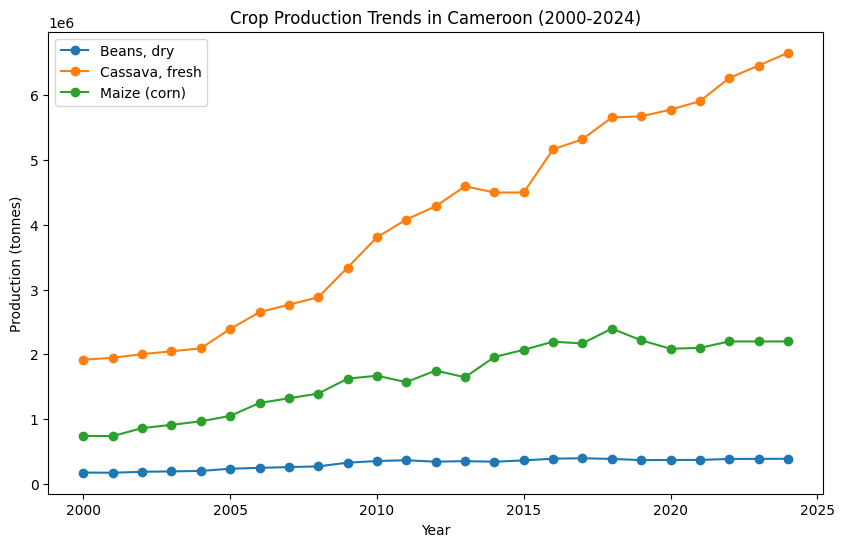

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for crop in selected_crops:
    crop_data = yearly[yearly["Item"] == crop]
    plt.plot(
        crop_data["Year"],
        crop_data["Production"],
        marker="o",
        label=crop
    )
plt.xlabel("Year")
plt.ylabel("Production (tonnes)")
plt.title("Crop Production Trends in Cameroon (2000-2024)")
plt.legend()
plt.show()

In [40]:
calculated_production = (
    crop_wide["Area harvested"]
    * crop_wide["Yield"]
    / 1000
)

difference = (
    calculated_production
    - crop_wide["Production"]
)

print(difference)
print(difference.abs().max())

0     -0.9185
1     -3.7134
2     -9.6309
3     10.8852
4      6.5504
       ...   
70    36.6027
71    50.2000
72   -10.0000
73   -40.0000
74   -40.0000
Length: 75, dtype: float64
50.200000000186265


In [49]:
import pandas as pd

prices = pd.read_csv(
    "market_prices.csv",
    encoding="latin-1",
    low_memory=False
)

print("Rows:", prices.shape[0])
print("Columns:", prices.columns.tolist())
print(prices.head())

Rows: 19824
Columns: ['ISO3', 'country', 'adm1_name', 'adm2_name', 'mkt_name', 'lat', 'lon', 'geo_id', 'price_date', 'year', 'month', 'currency', 'components', 'start_dense_data', 'last_survey_point', 'data_coverage', 'data_coverage_recent', 'index_confidence_score', 'spatially_interpolated', 'bananas', 'beans_fao', 'cassava', 'cassava_fao', 'cocoyam_fao', 'fish_mackerel', 'maize', 'maize_fao', 'meat_beef', 'oil', 'plantains_fao', 'potatoes_fao', 'rice', 'rice_fao', 'wheat_flour', 'wheat_flour_fao', 'o_bananas', 'h_bananas', 'l_bananas', 'c_bananas', 'inflation_bananas', 'trust_bananas', 'o_beans_fao', 'h_beans_fao', 'l_beans_fao', 'c_beans_fao', 'inflation_beans_fao', 'trust_beans_fao', 'o_cassava', 'h_cassava', 'l_cassava', 'c_cassava', 'inflation_cassava', 'trust_cassava', 'o_cassava_fao', 'h_cassava_fao', 'l_cassava_fao', 'c_cassava_fao', 'inflation_cassava_fao', 'trust_cassava_fao', 'o_cocoyam_fao', 'h_cocoyam_fao', 'l_cocoyam_fao', 'c_cocoyam_fao', 'inflation_cocoyam_fao', 'trust

In [50]:
print(prices[["country", "mkt_name", "price_date", "currency"]].head())

    country mkt_name  price_date currency
0  Cameroon  Adoumri  01-01-2007      XAF
1  Cameroon  Adoumri  01-02-2007      XAF
2  Cameroon  Adoumri  01-03-2007      XAF
3  Cameroon  Adoumri  01-04-2007      XAF
4  Cameroon  Adoumri  01-05-2007      XAF


In [51]:
print(prices["mkt_name"].unique())

['Adoumri' 'Amchid??' 'Bafoussam' 'Bamenda' 'Bamenda-Nkwen' 'Bamyanga'
 'Banyo' 'Barombi Kang' 'Batoua Godol??' 'Batouri' 'Bertoua 1' 'Bertoua 2'
 'Betare Oya' 'Buea' 'Douala-Bonaberi' 'Douala-Congo'
 'Douala-March?? Central' 'Douala-Sandaga' 'Doukoula' 'Figuil' 'Fotokol'
 'Fundong' 'Galim tign??re' 'Garoua' 'Garoua Boula??' 'Gazawa' 'Gbiti'
 'Gobo' 'God??' 'Guider' 'Guiwa Yangamo' 'Guzang' 'Kaele' 'Kentzou'
 'K??tt??' 'Kolofata' 'Kousseri' 'Koza' 'Kumba' 'Kumbo' 'Limb??'
 'Logone-Birni' 'Mada' 'Madingring' 'Mamf??' 'Mandjou' 'Mara' 'Maroua'
 'Maroua-Dougoy' 'Mayo Darl??' 'Mayo galke' 'Mayo Oulo' 'Mbaiboum' 'Mb??'
 'Meiganga' 'Mogode' 'Mokolo' 'Mora' 'Muea' 'Mutengene' 'Ndokayo' 'Ndop'
 'Ngaoui' 'Ngaound??r??' 'Ngong' 'Nkambe' 'Pintchoumba' 'Pitoa' 'Poli'
 'Rey Bouba' 'Salak' 'Tibati' 'Tign??re' 'Tiko' 'Tokombere'
 'Tongo Gandima' 'Wum' 'Yagoua' 'Yamba' 'Yaound??-March?? 8e'
 'Yaound??-Mfoundi' 'Yaound??-Mokolo' 'Zamay' 'Market Average']


In [52]:
target_markets = [
    "Bamenda",
    "Bamenda-Nkwen"
]

product_columns = [
    "beans_fao",
    "cassava",
    "maize",
    "maize_fao"
]

prices["price_date"] = pd.to_datetime(
    prices["price_date"],
    dayfirst=True,
    errors="coerce"
)

local_prices = prices[
    prices["mkt_name"].isin(target_markets)
].copy()

for column in product_columns:
    local_prices[column] = pd.to_numeric(
        local_prices[column],
        errors="coerce"
    )

print("Rows:", len(local_prices))

print(
    local_prices.groupby("mkt_name")["price_date"]
    .agg(["min", "max", "count"])
)

print("\nMissing prices:")
print(local_prices[product_columns].isna().sum())

print("\nSample:")
print(
    local_prices[
        ["mkt_name", "price_date"] + product_columns
    ].head(10)
)

Rows: 472
                     min        max  count
mkt_name                                  
Bamenda       2007-01-01 2026-08-01    236
Bamenda-Nkwen 2007-01-01 2026-08-01    236

Missing prices:
beans_fao    238
cassava      472
maize        315
maize_fao    238
dtype: int64

Sample:
    mkt_name price_date  beans_fao  cassava   maize  maize_fao
708  Bamenda 2007-01-01     392.93      NaN  199.64     199.64
709  Bamenda 2007-02-01     338.12      NaN  181.95     181.95
710  Bamenda 2007-03-01     466.74      NaN  193.24     193.24
711  Bamenda 2007-04-01     432.90      NaN  229.57     229.57
712  Bamenda 2007-05-01     432.90      NaN  229.57     229.57
713  Bamenda 2007-06-01     417.54      NaN  196.27     196.27
714  Bamenda 2007-07-01     418.85      NaN  200.24     200.24
715  Bamenda 2007-08-01     411.52      NaN  153.05     153.05
716  Bamenda 2007-09-01     378.79      NaN  135.07     135.07
717  Bamenda 2007-10-01     358.74      NaN  138.74     138.74


In [53]:
candidate_columns = [
    "beans_fao",
    "cassava",
    "cassava_fao",
    "maize",
    "maize_fao"
]

print(
    local_prices.groupby("mkt_name")[candidate_columns]
    .count()
)

               beans_fao  cassava  cassava_fao  maize  maize_fao
mkt_name                                                        
Bamenda              234        0            0    149        234
Bamenda-Nkwen          0        0            0      8          0


In [54]:
print(
    local_prices[candidate_columns]
    .describe()
)

        beans_fao  cassava  cassava_fao       maize   maize_fao
count  234.000000      0.0          0.0  157.000000  234.000000
mean   566.478761      NaN          NaN  252.765478  263.441453
std    115.868589      NaN          NaN   49.186007   42.848090
min    317.970000      NaN          NaN  135.070000  135.070000
25%    499.460000      NaN          NaN  222.000000  249.000000
50%    562.200000      NaN          NaN  256.340000  267.005000
75%    620.442500      NaN          NaN  286.300000  291.742500
max    979.570000      NaN          NaN  408.000000  353.000000


In [55]:
bamenda_prices = local_prices[
    local_prices["mkt_name"] == "Bamenda"
][
    ["price_date", "beans_fao", "maize_fao"]
].sort_values("price_date").copy()

print(bamenda_prices.head())
print(bamenda_prices.tail())
print("\nMissing values:")
print(bamenda_prices.isna().sum())

    price_date  beans_fao  maize_fao
708 2007-01-01     392.93     199.64
709 2007-02-01     338.12     181.95
710 2007-03-01     466.74     193.24
711 2007-04-01     432.90     229.57
712 2007-05-01     432.90     229.57
    price_date  beans_fao  maize_fao
939 2026-04-01     647.53     232.52
940 2026-05-01     647.84     243.96
941 2026-06-01     537.97     233.55
942 2026-07-01        NaN        NaN
943 2026-08-01        NaN        NaN

Missing values:
price_date    0
beans_fao     2
maize_fao     2
dtype: int64


In [56]:
for column in ["beans_fao", "maize_fao"]:
    series = (
        bamenda_prices
        .dropna(subset=[column])
        .set_index("price_date")[column]
    )

    expected_months = pd.date_range(
        series.index.min(),
        series.index.max(),
        freq="MS"
    )

    missing_months = expected_months.difference(series.index)

    print(column)
    print("First month:", series.index.min())
    print("Last observed month:", series.index.max())
    print("Missing months:", missing_months.tolist())

beans_fao
First month: 2007-01-01 00:00:00
Last observed month: 2026-06-01 00:00:00
Missing months: []
maize_fao
First month: 2007-01-01 00:00:00
Last observed month: 2026-06-01 00:00:00
Missing months: []


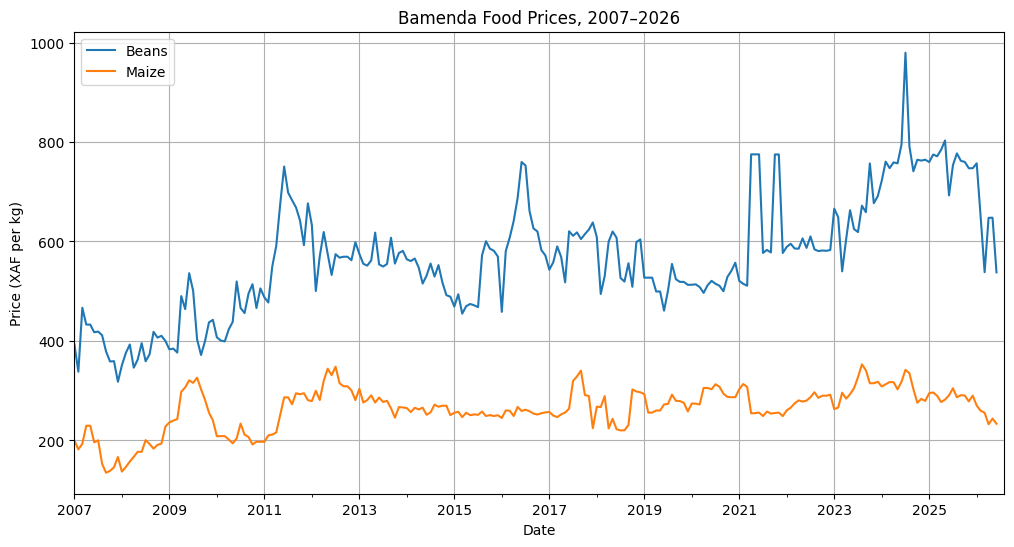

In [57]:
import matplotlib.pyplot as plt

plot_data = bamenda_prices.set_index("price_date")[
    ["beans_fao", "maize_fao"]
]

plot_data.plot(figsize=(12, 6))

plt.title("Bamenda Food Prices, 2007–2026")
plt.xlabel("Date")
plt.ylabel("Price (XAF per kg)")
plt.legend(["Beans", "Maize"])
plt.grid(True)
plt.show()

In [58]:
paired_prices = bamenda_prices.dropna(
    subset=["beans_fao", "maize_fao"]
).copy()

monthly_changes = paired_prices[
    ["beans_fao", "maize_fao"]
].pct_change() * 100

print("Monthly volatility:")
print(monthly_changes.std().round(2))

print("\nCorrelation between bean and maize prices:")
print(
    paired_prices["beans_fao"]
    .corr(paired_prices["maize_fao"])
)

Monthly volatility:
beans_fao    9.56
maize_fao    6.96
dtype: float64

Correlation between bean and maize prices:
0.5718134697084737


In [59]:
for column in ["beans_fao", "maize_fao"]:
    series = (
        bamenda_prices
        .dropna(subset=[column])
        .set_index("price_date")[column]
        .sort_index()
    )

    actual = series.iloc[-12:]
    predicted = series.shift(12).loc[actual.index]

    error = actual - predicted

    mae = error.abs().mean()
    mape = (error.abs() / actual * 100).mean()

    print("\n", column)
    print("MAE:", round(mae, 2), "XAF/kg")
    print("MAPE:", round(mape, 2), "%")


 beans_fao
MAE: 92.17 XAF/kg
MAPE: 14.69 %

 maize_fao
MAE: 30.28 XAF/kg
MAPE: 11.64 %


In [60]:
for column in ["beans_fao", "maize_fao"]:
    series = (
        bamenda_prices
        .dropna(subset=[column])
        .set_index("price_date")[column]
        .sort_index()
    )

    actual = series.iloc[-12:]
    predicted = series.shift(1).loc[actual.index]

    error = actual - predicted

    mae = error.abs().mean()
    mape = (error.abs() / actual * 100).mean()

    print("\n", column)
    print("Previous-month MAE:", round(mae, 2), "XAF/kg")
    print("Previous-month MAPE:", round(mape, 2), "%")


 beans_fao
Previous-month MAE: 46.9 XAF/kg
Previous-month MAPE: 7.58 %

 maize_fao
Previous-month MAE: 11.66 XAF/kg
Previous-month MAPE: 4.41 %


In [61]:
for column in ["beans_fao", "maize_fao"]:
    series = (
        bamenda_prices
        .dropna(subset=[column])
        .set_index("price_date")[column]
        .sort_index()
    )

    actual = series.iloc[-12:]

    predicted = (
        series.shift(1)
        .rolling(3)
        .mean()
        .loc[actual.index]
    )

    error = actual - predicted

    mae = error.abs().mean()
    mape = (error.abs() / actual * 100).mean()

    print("\n", column)
    print("Three-month average MAE:", round(mae, 2), "XAF/kg")
    print("Three-month average MAPE:", round(mape, 2), "%")


 beans_fao
Three-month average MAE: 40.36 XAF/kg
Three-month average MAPE: 6.71 %

 maize_fao
Three-month average MAE: 12.29 XAF/kg
Three-month average MAPE: 4.7 %


In [62]:
beans_series = (
    bamenda_prices
    .dropna(subset=["beans_fao"])
    .set_index("price_date")["beans_fao"]
    .sort_index()
)

maize_series = (
    bamenda_prices
    .dropna(subset=["maize_fao"])
    .set_index("price_date")["maize_fao"]
    .sort_index()
)

beans_forecast = beans_series.tail(3).mean()
maize_forecast = maize_series.iloc[-1]

last_observed_month = beans_series.index.max()
next_month = last_observed_month + pd.offsets.MonthBegin(1)

print("Forecast month:", next_month.strftime("%Y-%m"))
print("Beans forecast:", round(beans_forecast, 2), "XAF/kg")
print("Maize forecast:", round(maize_forecast, 2), "XAF/kg")

Forecast month: 2026-07
Beans forecast: 611.11 XAF/kg
Maize forecast: 233.55 XAF/kg


In [63]:
future_dates = pd.date_range(
    start=beans_series.index.max() + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

# Beans: recursively use the previous 3-month average
beans_history = beans_series.tolist()
beans_forecasts = []

for date in future_dates:
    next_price = sum(beans_history[-3:]) / 3
    beans_forecasts.append(next_price)
    beans_history.append(next_price)

# Maize: recursively use the previous month's price
maize_history = maize_series.tolist()
maize_forecasts = []

for date in future_dates:
    next_price = maize_history[-1]
    maize_forecasts.append(next_price)
    maize_history.append(next_price)

forecast_12_months = pd.DataFrame({
    "forecast_month": future_dates,
    "beans_forecast": beans_forecasts,
    "maize_forecast": maize_forecasts
})

print(forecast_12_months)

   forecast_month  beans_forecast  maize_forecast
0      2026-07-01      611.113333          233.55
1      2026-08-01      598.974444          233.55
2      2026-09-01      582.685926          233.55
3      2026-10-01      597.591235          233.55
4      2026-11-01      593.083868          233.55
5      2026-12-01      591.120343          233.55
6      2027-01-01      593.931815          233.55
7      2027-02-01      592.712009          233.55
8      2027-03-01      592.588056          233.55
9      2027-04-01      593.077293          233.55
10     2027-05-01      592.792453          233.55
11     2027-06-01      592.819267          233.55


In [64]:
forecast_12_months["beans_lower"] = (
    forecast_12_months["beans_forecast"] - 40.36
)

forecast_12_months["beans_upper"] = (
    forecast_12_months["beans_forecast"] + 40.36
)

forecast_12_months["maize_lower"] = (
    forecast_12_months["maize_forecast"] - 11.66
)

forecast_12_months["maize_upper"] = (
    forecast_12_months["maize_forecast"] + 11.66
)

print(forecast_12_months)

   forecast_month  beans_forecast  maize_forecast  beans_lower  beans_upper  \
0      2026-07-01      611.113333          233.55   570.753333   651.473333   
1      2026-08-01      598.974444          233.55   558.614444   639.334444   
2      2026-09-01      582.685926          233.55   542.325926   623.045926   
3      2026-10-01      597.591235          233.55   557.231235   637.951235   
4      2026-11-01      593.083868          233.55   552.723868   633.443868   
5      2026-12-01      591.120343          233.55   550.760343   631.480343   
6      2027-01-01      593.931815          233.55   553.571815   634.291815   
7      2027-02-01      592.712009          233.55   552.352009   633.072009   
8      2027-03-01      592.588056          233.55   552.228056   632.948056   
9      2027-04-01      593.077293          233.55   552.717293   633.437293   
10     2027-05-01      592.792453          233.55   552.432453   633.152453   
11     2027-06-01      592.819267          233.55   

In [65]:
def create_price_features(data, price_column):
    model_data = data[
        ["price_date", price_column]
    ].dropna().copy()

    model_data = model_data.rename(
        columns={price_column: "price"}
    )

    model_data = model_data.sort_values("price_date")

    model_data["lag_1"] = model_data["price"].shift(1)
    model_data["lag_2"] = model_data["price"].shift(2)
    model_data["lag_3"] = model_data["price"].shift(3)
    model_data["lag_6"] = model_data["price"].shift(6)
    model_data["lag_12"] = model_data["price"].shift(12)

    model_data["rolling_mean_3"] = (
        model_data["price"]
        .shift(1)
        .rolling(3)
        .mean()
    )

    model_data["month"] = (
        model_data["price_date"].dt.month
    )

    return model_data.dropna()


beans_model_data = create_price_features(
    bamenda_prices,
    "beans_fao"
)

maize_model_data = create_price_features(
    bamenda_prices,
    "maize_fao"
)

print(beans_model_data.head())
print(beans_model_data.shape)

print(maize_model_data.head())
print(maize_model_data.shape)

    price_date   price   lag_1   lag_2   lag_3   lag_6  lag_12  \
720 2008-01-01  351.19  317.97  359.39  358.74  418.85  392.93   
721 2008-02-01  375.94  351.19  317.97  359.39  411.52  338.12   
722 2008-03-01  392.93  375.94  351.19  317.97  378.79  466.74   
723 2008-04-01  346.32  392.93  375.94  351.19  358.74  432.90   
724 2008-05-01  362.65  346.32  392.93  375.94  359.39  432.90   

     rolling_mean_3  month  
720      345.366667      1  
721      342.850000      2  
722      348.366667      3  
723      373.353333      4  
724      371.730000      5  
(222, 9)
    price_date   price   lag_1   lag_2   lag_3   lag_6  lag_12  \
720 2008-01-01  137.33  166.68  145.97  138.74  200.24  199.64   
721 2008-02-01  146.61  137.33  166.68  145.97  153.05  181.95   
722 2008-03-01  157.51  146.61  137.33  166.68  135.07  193.24   
723 2008-04-01  167.05  157.51  146.61  137.33  138.74  229.57   
724 2008-05-01  177.23  167.05  157.51  146.61  145.97  229.57   

     rolling_mean_3  mo

In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd


def train_random_forest(model_data):
    feature_columns = [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_6",
        "lag_12",
        "rolling_mean_3",
        "month"
    ]

    # Keep the final 12 months for testing
    train_data = model_data.iloc[:-12]
    test_data = model_data.iloc[-12:]

    X_train = train_data[feature_columns]
    y_train = train_data["price"]

    X_test = test_data[feature_columns]
    y_test = test_data["price"]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mape = (
        abs(y_test - predictions)
        / y_test
        * 100
    ).mean()

    results = test_data[["price_date", "price"]].copy()
    results["prediction"] = predictions

    importance = pd.Series(
        model.feature_importances_,
        index=feature_columns
    ).sort_values(ascending=False)

    return model, results, mae, mape, importance


beans_model, beans_results, beans_mae, beans_mape, beans_importance = (
    train_random_forest(beans_model_data)
)

maize_model, maize_results, maize_mae, maize_mape, maize_importance = (
    train_random_forest(maize_model_data)
)

print("Beans Random Forest")
print("MAE:", round(beans_mae, 2), "XAF/kg")
print("MAPE:", round(beans_mape, 2), "%")
print(beans_importance)

print("\nMaize Random Forest")
print("MAE:", round(maize_mae, 2), "XAF/kg")
print("MAPE:", round(maize_mape, 2), "%")
print(maize_importance)

Beans Random Forest
MAE: 34.11 XAF/kg
MAPE: 5.59 %
lag_1             0.669109
rolling_mean_3    0.174276
lag_6             0.041395
lag_12            0.039453
lag_2             0.035002
lag_3             0.024757
month             0.016007
dtype: float64

Maize Random Forest
MAE: 11.66 XAF/kg
MAPE: 4.42 %
lag_1             0.775511
rolling_mean_3    0.094752
lag_2             0.043160
lag_3             0.036561
lag_12            0.021055
lag_6             0.014880
month             0.014081
dtype: float64


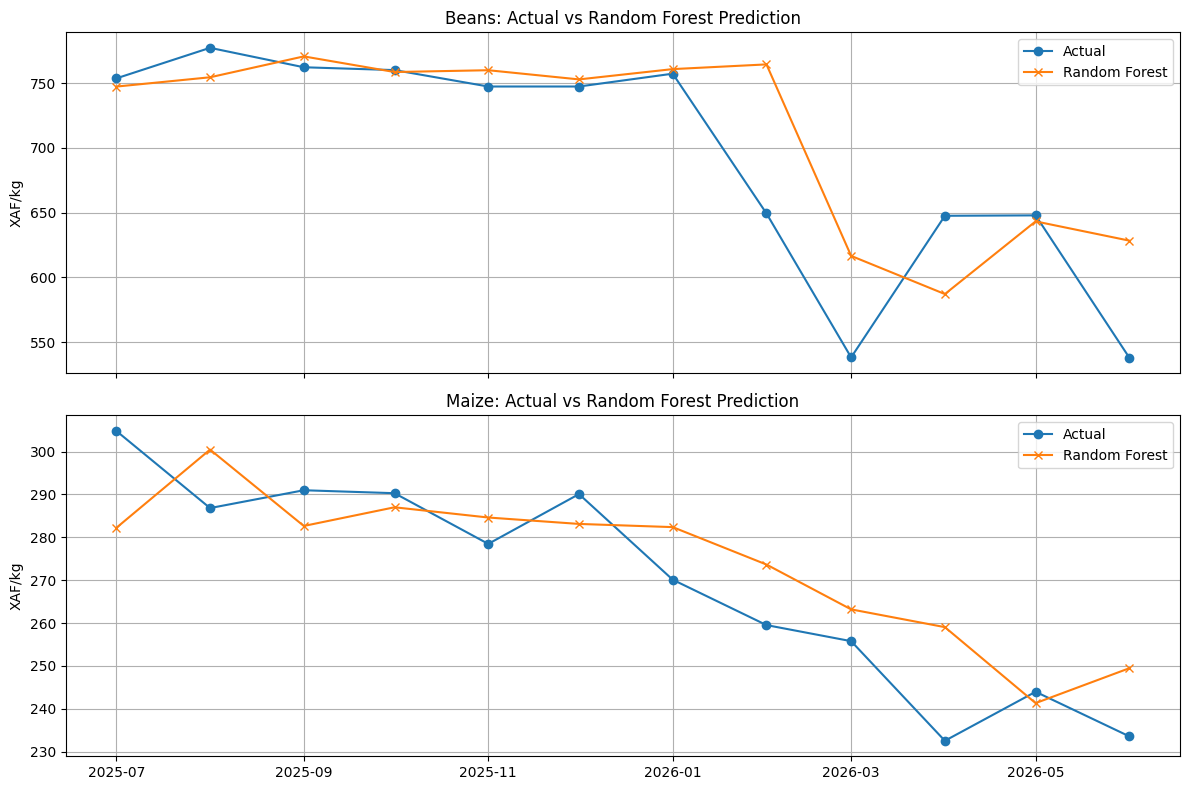

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

axes[0].plot(
    beans_results["price_date"],
    beans_results["price"],
    marker="o",
    label="Actual"
)

axes[0].plot(
    beans_results["price_date"],
    beans_results["prediction"],
    marker="x",
    label="Random Forest"
)

axes[0].set_title("Beans: Actual vs Random Forest Prediction")
axes[0].set_ylabel("XAF/kg")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    maize_results["price_date"],
    maize_results["price"],
    marker="o",
    label="Actual"
)

axes[1].plot(
    maize_results["price_date"],
    maize_results["prediction"],
    marker="x",
    label="Random Forest"
)

axes[1].set_title("Maize: Actual vs Random Forest Prediction")
axes[1].set_ylabel("XAF/kg")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [71]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error


def evaluate_exponential_smoothing(model_data):
    series = (
        model_data
        .set_index("price_date")["price"]
        .sort_index()
        .asfreq("MS")
    )

    train_data = series.iloc[:-12]
    test_data = series.iloc[-12:]

    model = ExponentialSmoothing(
        train_data,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )

    fitted_model = model.fit()

    predictions = fitted_model.forecast(
        len(test_data)
    )

    actual = test_data.to_numpy()
    predicted = predictions.to_numpy()

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mape = (
        abs(actual - predicted)
        / actual
        * 100
    ).mean()

    return mae, mape


beans_es_mae, beans_es_mape = evaluate_exponential_smoothing(
    beans_model_data
)

maize_es_mae, maize_es_mape = evaluate_exponential_smoothing(
    maize_model_data
)

print("Beans Exponential Smoothing")
print("MAE:", round(beans_es_mae, 2), "XAF/kg")
print("MAPE:", round(beans_es_mape, 2), "%")

print("\nMaize Exponential Smoothing")
print("MAE:", round(maize_es_mae, 2), "XAF/kg")
print("MAPE:", round(maize_es_mape, 2), "%")

Beans Exponential Smoothing
MAE: 73.15 XAF/kg
MAPE: 11.97 %

Maize Exponential Smoothing
MAE: 27.58 XAF/kg
MAPE: 11.06 %


In [72]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd


feature_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "month"
]


def train_final_random_forest(model_data):
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2
    )

    model.fit(
        model_data[feature_columns],
        model_data["price"]
    )

    return model


def recursive_rf_forecast(model, model_data, future_dates):
    history = model_data["price"].tolist()
    forecasts = []

    for date in future_dates:
        feature_row = pd.DataFrame([{
            "lag_1": history[-1],
            "lag_2": history[-2],
            "lag_3": history[-3],
            "lag_6": history[-6],
            "lag_12": history[-12],
            "rolling_mean_3": sum(history[-3:]) / 3,
            "month": date.month
        }])

        prediction = model.predict(feature_row)[0]

        forecasts.append(prediction)
        history.append(prediction)

    return forecasts


# Retrain beans model on all available data
final_beans_model = train_final_random_forest(
    beans_model_data
)

# Create the future dates
last_observed_date = beans_model_data["price_date"].max()

future_dates = pd.date_range(
    start=last_observed_date + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

# Forecast beans recursively
beans_forecasts = recursive_rf_forecast(
    final_beans_model,
    beans_model_data,
    future_dates
)

# Maize uses the previous-month method
latest_maize_price = maize_model_data["price"].iloc[-1]

maize_forecasts = [
    latest_maize_price
] * len(future_dates)


# Build final forecast table
final_forecast = pd.DataFrame({
    "forecast_month": future_dates,
    "beans_forecast": beans_forecasts,
    "maize_forecast": maize_forecasts
})

# Typical error bands from our validation results
final_forecast["beans_lower"] = (
    final_forecast["beans_forecast"] - 34.11
)

final_forecast["beans_upper"] = (
    final_forecast["beans_forecast"] + 34.11
)

final_forecast["maize_lower"] = (
    final_forecast["maize_forecast"] - 11.66
)

final_forecast["maize_upper"] = (
    final_forecast["maize_forecast"] + 11.66
)

final_forecast = final_forecast.round(2)

print(final_forecast)

   forecast_month  beans_forecast  maize_forecast  beans_lower  beans_upper  \
0      2026-07-01          599.38          233.55       565.27       633.49   
1      2026-08-01          624.07          233.55       589.96       658.18   
2      2026-09-01          595.56          233.55       561.45       629.67   
3      2026-10-01          584.10          233.55       549.99       618.21   
4      2026-11-01          594.80          233.55       560.69       628.91   
5      2026-12-01          592.13          233.55       558.02       626.24   
6      2027-01-01          581.97          233.55       547.86       616.08   
7      2027-02-01          583.09          233.55       548.98       617.20   
8      2027-03-01          588.91          233.55       554.80       623.02   
9      2027-04-01          592.60          233.55       558.49       626.71   
10     2027-05-01          593.95          233.55       559.84       628.06   
11     2027-06-01          590.26          233.55   

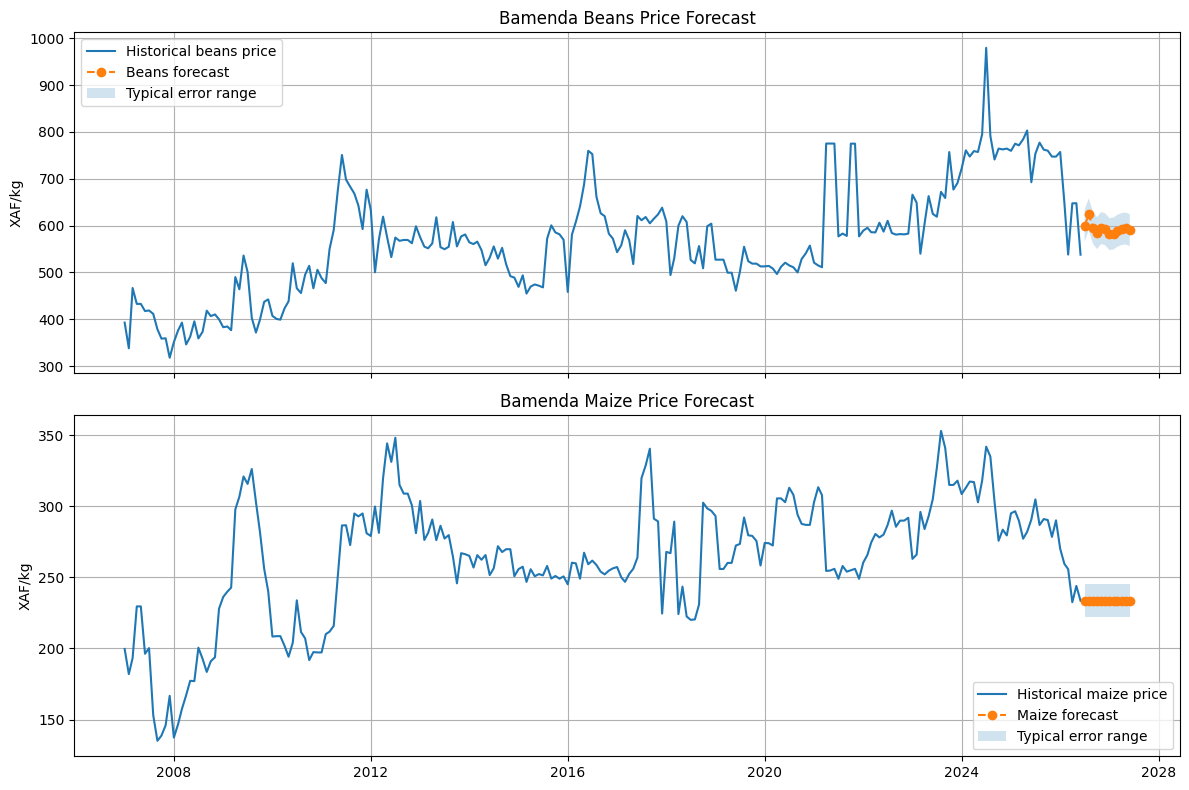

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

# Beans
axes[0].plot(
    bamenda_prices["price_date"],
    bamenda_prices["beans_fao"],
    label="Historical beans price"
)

axes[0].plot(
    final_forecast["forecast_month"],
    final_forecast["beans_forecast"],
    linestyle="--",
    marker="o",
    label="Beans forecast"
)

axes[0].fill_between(
    final_forecast["forecast_month"],
    final_forecast["beans_lower"],
    final_forecast["beans_upper"],
    alpha=0.2,
    label="Typical error range"
)

axes[0].set_title("Bamenda Beans Price Forecast")
axes[0].set_ylabel("XAF/kg")
axes[0].legend()
axes[0].grid(True)

# Maize
axes[1].plot(
    bamenda_prices["price_date"],
    bamenda_prices["maize_fao"],
    label="Historical maize price"
)

axes[1].plot(
    final_forecast["forecast_month"],
    final_forecast["maize_forecast"],
    linestyle="--",
    marker="o",
    label="Maize forecast"
)

axes[1].fill_between(
    final_forecast["forecast_month"],
    final_forecast["maize_lower"],
    final_forecast["maize_upper"],
    alpha=0.2,
    label="Typical error range"
)

axes[1].set_title("Bamenda Maize Price Forecast")
axes[1].set_ylabel("XAF/kg")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [74]:
final_forecast.to_csv(
    "bamenda_price_forecast.csv",
    index=False
)

In [75]:
evaluation = pd.DataFrame({
    "product": [
        "Beans", "Beans", "Beans", "Beans", "Beans",
        "Maize", "Maize", "Maize", "Maize", "Maize"
    ],
    "method": [
        "Seasonal naive",
        "Previous month",
        "Three-month average",
        "Random Forest",
        "Exponential Smoothing",
        "Seasonal naive",
        "Previous month",
        "Three-month average",
        "Random Forest",
        "Exponential Smoothing"
    ],
    "MAE_XAF_per_kg": [
        92.17, 46.90, 40.36, 34.11, 73.15,
        30.28, 11.66, 12.29, 11.66, 27.58
    ],
    "MAPE_percent": [
        14.69, 7.58, 6.71, 5.59, 11.97,
        11.64, 4.41, 4.70, 4.42, 11.06
    ]
})

print(evaluation)

print("\nRanked by MAPE:")
print(
    evaluation.sort_values(
        ["product", "MAPE_percent"]
    )
)

  product                 method  MAE_XAF_per_kg  MAPE_percent
0   Beans         Seasonal naive           92.17         14.69
1   Beans         Previous month           46.90          7.58
2   Beans    Three-month average           40.36          6.71
3   Beans          Random Forest           34.11          5.59
4   Beans  Exponential Smoothing           73.15         11.97
5   Maize         Seasonal naive           30.28         11.64
6   Maize         Previous month           11.66          4.41
7   Maize    Three-month average           12.29          4.70
8   Maize          Random Forest           11.66          4.42
9   Maize  Exponential Smoothing           27.58         11.06

Ranked by MAPE:
  product                 method  MAE_XAF_per_kg  MAPE_percent
3   Beans          Random Forest           34.11          5.59
2   Beans    Three-month average           40.36          6.71
1   Beans         Previous month           46.90          7.58
4   Beans  Exponential Smoothing      

In [76]:
evaluation.to_csv(
    "model_evaluation.csv",
    index=False
)